In [2]:
import pandas as pd
df = pd.read_csv('online_retail_II.csv',encoding='ISO-8859-1')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
print("pehle data me kul records the:", df.shape[0])
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['TotalAmount'] = df['Quantity'] * df['Price']
print("saaf krne ke baad bache kul records :", df.shape[0])
df.head()

pehle data me kul records the: 805549
saaf krne ke baad bache kul records : 805549


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [10]:
# 'InvoiceDate' column ko datetime format me badal rahe hain
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Dataset ki sabse aakhiri date se 1 din aage ki date set kar rahe hain reference ke liye
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Har Customer ke liye RFM metrics calculate kar rahe hain
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency (Din)
    'Invoice': 'nunique',                                      # Frequency (Orders)
    'TotalAmount': 'sum'                                      # Monetary (Total Kharcha)
})

# Columns ke naam sahi kar rahe hain
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# RFM table ka preview dekhne ke liye
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [11]:
# qcut use karke data ko 5 barabar hisson (quintiles) me baant rahe hain
# Recency me jitne kam din (chhoti value), utna achha score (5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency aur Monetary me jitni badi value, utna achha score (5)
# rank(method='first') isliye lagaya hai taaki duplicate values me error na aaye
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Teeno scores ko jodkar ek final combine score bana rahe hain (jaise: '555')
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Scores ke sath table ka preview dekhne ke liye
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,5,5,255
12347.0,2,8,5633.32,5,4,5,545
12348.0,75,5,2019.40,3,4,4,344
12349.0,19,4,4428.69,5,3,5,535
12350.0,310,1,334.40,2,1,2,212


--- Har Segment me Customers ka Count ---
Segment
Hibernating            1523
Loyal Customers        1161
Champions               837
At Risk                 753
Potential Loyalists     714
About to Sleep          385
Need Attention          266
Promising               114
Can't Loose Them         71
New Customers            54
Name: count, dtype: int64


C:\Users\heman\AppData\Local\Temp\ipykernel_14400\3128726401.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


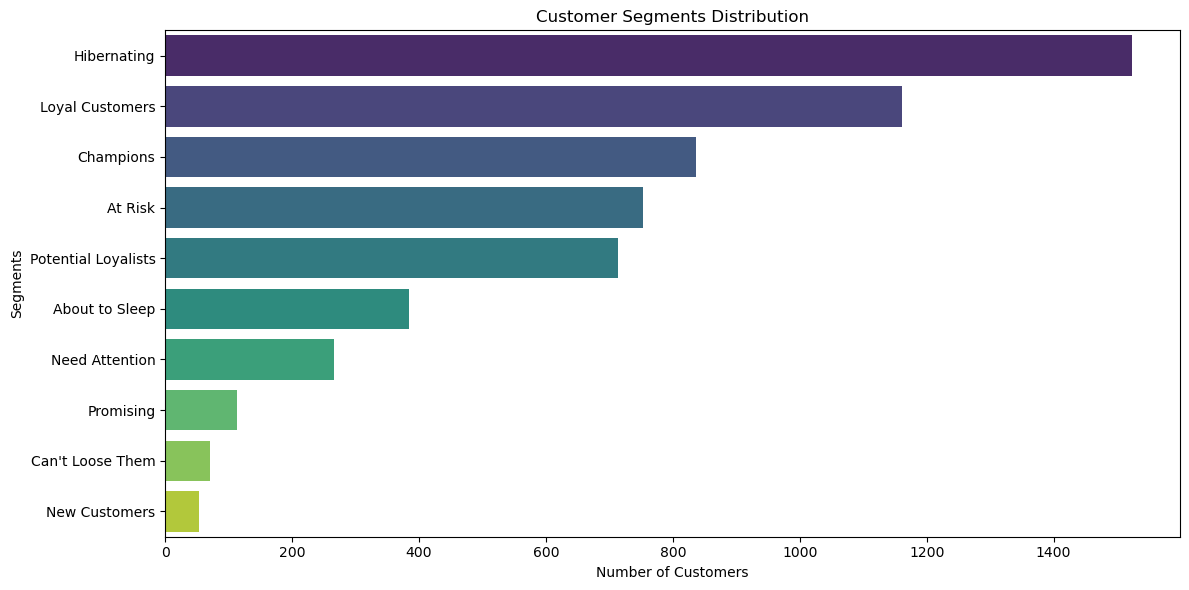

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# RFM Score ke hisab se segments define kar rahe hain (Standard Marketing Rules)
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

# R_Score aur F_Score ko jodkar segments apply kar rahe hain
rfm['Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(seg_map, regex=True)

# 1. Pehle dekhte hain har segment me kitne customers hain
print("--- Har Segment me Customers ka Count ---")
print(rfm['Segment'].value_counts())

# 2. Ab iska ek mast visual graph (Chart) banate hain
plt.figure(figsize=(12, 6))
sns.countplot(data=rfm, y='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segments Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Segments')
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# 1. Har customer ki sabse aakhiri khareedari ki date nikal rahe hain
customer_last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()

# 2. Hum data ki aakhiri date se 90 din pehle ki ek boundary date set kar rahe hain
churn_threshold_date = snapshot_date - pd.Timedelta(days=90)

# 3. Agar aakhiri purchase 90 din se pehle ki hai toh 1 (Bhag gaya), nahi toh 0 (Active)
customer_last_purchase['Churn'] = customer_last_purchase['InvoiceDate'].apply(lambda x: 1 if x < churn_threshold_date else 0)

# 4. Is Churn column ko hamari rfm table ke sath jod rahe hain
rfm = rfm.merge(customer_last_purchase[['Customer ID', 'Churn']], on='Customer ID', how='left')

# Check karte hain ki hamari mehnat rang layi ya nahi
print("Churn data ka asli count (0 = Active, 1 = Churned):")
print(rfm['Churn'].value_counts())
rfm.head()

Churn data ka asli count (0 = Active, 1 = Churned):
Churn
1    2998
0    2880
Name: count, dtype: int64


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Churn
0,12346.0,326,12,77556.46,2,5,5,255,Can't Loose Them,1
1,12347.0,2,8,5633.32,5,4,5,545,Champions,0
2,12348.0,75,5,2019.40,3,4,4,344,Loyal Customers,0
3,12349.0,19,4,4428.69,5,3,5,535,Potential Loyalists,0
4,12350.0,310,1,334.40,2,1,2,212,Hibernating,1


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Input me hum de rahe hain Recency, Frequency, aur Monetary aur Target hai Churn
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

# 80% data seekhne ke liye (Train) aur 20% test karne ke liye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Data ko scale kar rahe hain taaki machine confuse na ho
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Bhai, data bilkul tayaar hai Machine Learning ke liye!")
print(f"Sikhane ke liye records: {X_train_scaled.shape[0]}, Test karne ke liye: {X_test_scaled.shape[0]}")

Bhai, data bilkul tayaar hai Machine Learning ke liye!
Sikhane ke liye records: 4702, Test karne ke liye: 1176


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Model train ho raha hai
ml_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
ml_model.fit(X_train_scaled, y_train)

# Test data par prediction nikal rahe hain
y_pred = ml_model.predict(X_test_scaled)
y_prob = ml_model.predict_proba(X_test_scaled)[:, 1]


print(classification_report(y_test, y_pred))
print("ROC AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       576
           1       1.00      1.00      1.00       600

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

ROC AUC Score: 1.0


In [17]:
import pickle

# Model aur Scaler ko dukan ke folder me permanently save kar rahe hain
with open('churn_model.pkl', 'wb') as model_file:
    pickle.dump(ml_model, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

# Saath me rfm table ko bhi csv me save kar lete hain dashboard ke liye
rfm.to_csv('rfm_dashboard_data.csv')

print("Bhai, model aur data files successfully save ho gayi hain!")

Bhai, model aur data files successfully save ho gayi hain!
